# 02. Source model selection with a chi-squared decision tree

Notebook 01 selects each source's morphology either from MER's Sersic
fit (``PRIOR["model_selection"] = "prior"``) or from a chi-squared
decision tree (``PRIOR["model_selection"] = "tree"``). This notebook
examines the tree on a
50 arcsec field in which a single blob containing a galaxy and a point
source provides a clear test case.

The tree is reimplemented from The Farmer (Weaver et al. 2023, ApJS
269, 20), with thresholds tuned to Q1 data quality. The ladder, in
order of increasing complexity, is

    PointSource -> SimpleGalaxy -> ExpGalaxy -> DevGalaxy -> FixedCompositeGalaxy

where SimpleGalaxy, an exponential profile with a fixed circular
shape, serves as the marginally resolved bridge tier.


## 1. Imports and target


In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
from astropy.table import Table

import euclid_phot as ep

TARGET_RA = 269.48
TARGET_DEC = 67.30
CUTOUT_SIZE_ARCSEC = 50.0   # use the small bundled cutout for the algorithm walkthrough
DATA_DIR = Path(os.environ.get("EUCLID_PHOT_DATA_DIR", "../examples/data"))
SHOW_DOWNLOAD_PATH = False


## 2. Load the bundled 50 arcsec cutout and the MER catalog


In [2]:
mer_path = DATA_DIR / f"mer_catalog_{TARGET_RA:.4f}_{TARGET_DEC:.4f}_{int(CUTOUT_SIZE_ARCSEC)}.fits"
if mer_path.exists() and not SHOW_DOWNLOAD_PATH:
    mer_cat = Table.read(mer_path)
else:
    half_size_deg = CUTOUT_SIZE_ARCSEC / 2.0 / 3600.0
    mer_cat = ep.query_mer_catalog(TARGET_RA, TARGET_DEC, half_size_deg)
vis = ep.fetch_cutout("VIS", TARGET_RA, TARGET_DEC, CUTOUT_SIZE_ARCSEC,
                      data_dir=DATA_DIR / "cutouts",
                      show_download_path=SHOW_DOWNLOAD_PATH)
mer_cat = ep.trim_catalog_to_cutout(mer_cat, vis.wcs, vis.shape)
print(f"{len(mer_cat)} sources in the cutout")


63 sources in the cutout


## 3. Build the Tractor image


In [3]:
psf_data = ep.extract_catalog_psf(
    "VIS", TARGET_RA, TARGET_DEC, radius_arcsec=60.0,
    data_dir=DATA_DIR / "psf", show_download_path=SHOW_DOWNLOAD_PATH)
psf_stamp, psf_fwhm_arcsec = ep.psf_summary(psf_data)
tim_vis = ep.build_tractor_image(vis, psf_stamp)


## 4. SEP blob detection

A blob is a connected region of pixels above ``threshold_sigma`` * sigma
(here 1.5 sigma) containing at least ``minarea`` pixels (here 5),
dilated by ``dilate_pix`` (here 4 pixels) to merge adjacent detections.
A blob may contain several MER sources, which become its members.


In [4]:
blobs, _, _ = ep.detect_blobs(
    vis.data, tim_vis.getInvvar(),
    threshold_sigma=1.5, minarea=5, dilate_pix=4)
blobs = ep.assign_mer_to_blobs(mer_cat, blobs, tim_vis.getWcs())
blobs_with_sources = [b for b in blobs if b.member_mer_indices]
sizes = {}
for b in blobs_with_sources:
    sizes.setdefault(len(b.member_mer_indices), 0)
    sizes[len(b.member_mer_indices)] += 1
print(f"blobs with at least one MER source: {len(blobs_with_sources)}")
print("source-count histogram:", dict(sorted(sizes.items())))


blobs with at least one MER source: 50
source-count histogram: {1: 42, 2: 7, 3: 1}


## 5. Per-source CATALOG-PSF stamps for the demo blob

Within a blob, the fit uses the CATALOG-PSF stamp of the blob's
brightest member (sharper than the field average), so the tree compares
models against the sharpest available reference. The per-source stamps
built below are passed in; ``fit_blob`` selects the brightest member's.


In [5]:
src_stamps = {}
for i, row in enumerate(mer_cat):
    stamp, _, _ = ep.get_psf_for_source(psf_data, row["ra"], row["dec"])
    src_stamps[i] = stamp


## 6. Run the tree on one 2-source blob


In [6]:
target_blob = None
for b in blobs_with_sources:
    if set(b.member_mer_indices) == {3, 9}:
        target_blob = b; break
if target_blob is None:
    target_blob = next((b for b in blobs_with_sources
                        if len(b.member_mer_indices) == 2), blobs_with_sources[0])
print(f"using blob {target_blob.blob_id} with members {target_blob.member_mer_indices}")


using blob 78 with members [3, 9]


In [7]:
selector = ep.ModelSelector(
    sufficient_thresh=1.5,
    simplegalaxy_penalty=0.05,
    exp_dev_similar_thresh=0.15,
    simplegalaxy_radius=0.30,
)
chosen, history = selector.fit_blob(
    target_blob, tim_vis, mer_cat, vis.pixel_scale_arcsec,
    history=True, psf_by_member=src_stamps,
)
for i, src in chosen.items():
    print(f"MER {i} -> {type(src).__name__}")


MER 3 -> DevGalaxy
MER 9 -> PointSource


## 7. Walk the chi-squared ladder per source


In [8]:
print(f"{'MER':>4s} {'stage':>5s} {'model':<22s} {'chi2_red':>9s} {'accepted':>9s}")
by_idx_stage = {(r.source_idx, r.stage): r for r in history.stages}
for idx in target_blob.member_mer_indices:
    for s in sorted({s for (_, s) in by_idx_stage}):
        rec = by_idx_stage.get((idx, s))
        if rec is None:
            continue
        print(f"{idx:>4d} {s:>5d} {rec.model_name:<22s} "
              f"{rec.chi2_red:>9.2f} {'YES' if rec.accepted else '':>9s}")


 MER stage model                   chi2_red  accepted
   3     1 SimpleGalaxy                7.26          
   3     2 PointSource                20.60          
   3     3 ExpGalaxy                   5.26          
   3     4 DevGalaxy                   0.72       YES
   3     5 CompositeGalaxy             1.04          
   3     6 SersicGalaxy(n=5.27)        0.31          
   9     1 SimpleGalaxy               10.02          
   9     2 PointSource                 0.42       YES


## 8. Reproduce the per-tier residual ladder (Weaver et al. 2023, Fig. 3)


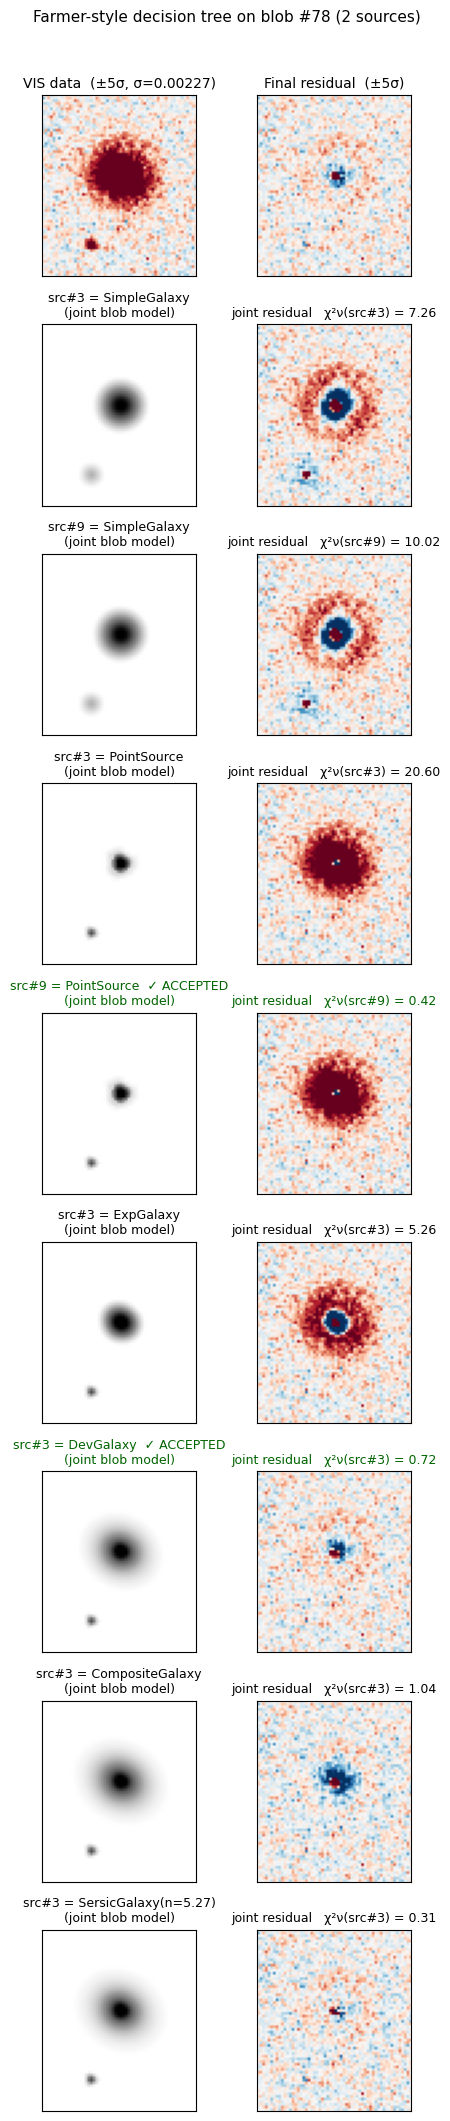

In [9]:
fig, _ = ep.reproduce_figure3(target_blob, history)
plt.show()


*With the package default (``full_ladder=True``) every blob member is
carried through the whole ladder and the tier with the lowest reduced
chi-squared wins, rather than stopping at the first tier below the
sufficiency threshold (the published first-sufficient shortcut, which on
this data biases faint fluxes low). The one early exit is an obvious
point source, which locks as PointSource before the galaxy tiers: MER 9
here. MER 3 is a galaxy, so it is fit at every tier and the argmin
selects DevGalaxy (as printed above). Adding free parameters lowers the
raw chi-squared but also the degrees of freedom, so the per-tier reduced
chi-squared is not monotonic along the ladder. The well-resolved
DevGalaxy still leaves a centrally peaked residual where a single de
Vaucouleurs profile cannot match the galaxy's true core (the profile
limitation discussed in section 9 of notebook 01). The guarded free-n
Sersic tier is also tried for this bright source, but it is kept only if
it beats the locked DevGalaxy by a fixed margin (``sersic_chi2_margin``,
0.1) on a wider acceptance window; here it does not, so DevGalaxy stands.
The Sersic row in the ladder above is scored on that wider window, not
the narrow per-source segment used for the earlier tiers, so its lower
chi-squared is not directly comparable to DevGalaxy's.*


## 9. Threshold sensitivity

The sufficiency threshold is swept across 1.0, 1.5, and 2.0, re-fitting
the demo blob. The decisions do not change. Under the full-ladder
default the galaxy (MER 3) is chosen by the lowest-chi-squared argmin,
which does not depend on the threshold at all; the threshold only gates
the early PointSource lock, and MER 9 sits far enough inside it that the
lock holds across the whole sweep. The threshold bites harder under the
first-sufficient shortcut (``full_ladder=False``) and for marginally
resolved sources whose reduced chi-squared lands near it. The package
default is 1.5, following Weaver et al. (2023).


In [10]:
for thresh in (1.0, 1.5, 2.0):
    sel = ep.ModelSelector(
        sufficient_thresh=thresh, simplegalaxy_penalty=0.05,
        exp_dev_similar_thresh=0.15, simplegalaxy_radius=0.30,
    )
    ch, hist = sel.fit_blob(
        target_blob, tim_vis, mer_cat, vis.pixel_scale_arcsec,
        history=True, psf_by_member=src_stamps)
    accepted = {r.source_idx: r.chi2_red for r in hist.stages if r.accepted}
    summary = "  ".join(
        f"MER{i}->{type(s).__name__}(chi2_red={accepted.get(i, float('nan')):.2f})"
        for i, s in ch.items())
    print(f"threshold={thresh}:  {summary}")


threshold=1.0:  MER3->DevGalaxy(chi2_red=0.72)  MER9->PointSource(chi2_red=0.42)


threshold=1.5:  MER3->DevGalaxy(chi2_red=0.72)  MER9->PointSource(chi2_red=0.42)


threshold=2.0:  MER3->DevGalaxy(chi2_red=0.72)  MER9->PointSource(chi2_red=0.42)


## 10. Run the tree over the full cutout (parallel)


In [11]:
sources_tree, _ = ep.run_model_selection(
    mer_cat, tim_vis, vis.data, tim_vis.getInvvar(),
    pixscale_arcsec=vis.pixel_scale_arcsec,
    n_workers=min(4, os.cpu_count() or 1),
)
print("model-class histogram from the chi-squared tree:")
class_hist = {}
for s in sources_tree:
    if s is None: continue
    class_hist[type(s).__name__] = class_hist.get(type(s).__name__, 0) + 1
for k in sorted(class_hist):
    print(f"  {k:<22s} {class_hist[k]}")


model-class histogram from the chi-squared tree:
  DevGalaxy              12
  ExpGalaxy              30
  FixedCompositeGalaxy   4
  PointSource            13


## 11. Suggested exercises

- Pick another two-source blob (inspect ``sizes`` and
  ``blobs_with_sources`` from section 4) and re-run from section 6. Two
  extended sources should both settle on ExpGalaxy or DevGalaxy rather
  than PointSource.
- Set ``simplegalaxy_penalty = 0`` in section 6 and re-run; the bridge
  tier is then accepted more often.
- Compare the per-source decisions with the MER-prior classes of
  notebook 01. They should agree for the bright, well-resolved sources
  and differ for the marginally extended ones.
